# 针对 TYL 的对手情报分析 —— 以 FPX 视角

**作者:** 孟庆喆

以 FPX 数据分析师的视角,对 TYL (TYLOO) 进行对手情报分析。
TYL 是 FPX 在 2026 VCT CN 启点赛首轮的实际对手。
本报告抓取 TYL 2026 赛季的全部职业对局数据,从地图偏好与 ban/pick、
阵容选择、攻防强弱等维度量化其战术特征,并落到针对性的 BP 建议与反制策略。

**数据来源:** VLR.gg(经 vlrdevapi 抓取)。原始数据已由 `scrape.py` 落地。
本 Notebook 不联网,可一键复现。

---

## 0. 环境与数据载入

In [1]:
import json, os, glob
from collections import Counter, defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# 中文显示。Windows 用 SimHei / Microsoft YaHei
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC', 'Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False

RAW_DIR = 'data/raw'
FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs('data/clean', exist_ok=True)

TYL_SHORT = 'TYL'   # 在数据里识别 TYL 的标识。VLR 一致用 "TYL"

# 载入抓取结果
with open(f'{RAW_DIR}/match_list.json', encoding='utf-8') as f:
    match_list = json.load(f)
series_files = sorted(glob.glob(f'{RAW_DIR}/series/*.json'))
series_data = []
for p in series_files:
    with open(p, encoding='utf-8') as f:
        series_data.append(json.load(f))

print(f'对局(BO)总数: {len(match_list)}')
print(f'抓到详情的系列赛数: {len(series_data)}')

对局(BO)总数: 26
抓到详情的系列赛数: 26


## 1. 数据清洗与结构化

把嵌套的 JSON 整理成四张扁平表:

- `maps_df` —— 每局地图一行(分析主力)
- `comps_df` —— 每队每局阵容一行
- `rounds_df` —— 每个回合一行
- `picks_bans_df` —— 每次 ban/pick 动作一行(BP 阶段分析专用)

**字段说明已对齐 vlrdevapi 实际返回结构。**

In [2]:
# --- 1.1 maps_df: 每局地图一行 ---
map_rows = []
for s in series_data:
    info = s['info']
    series_id = info['match_id']
    event = info.get('event', '')
    event_phase = info.get('event_phase', '')
    date = info.get('date', '')

    for mp in s['maps']:
        # 跳过"All"汇总条目(map_name=="All")
        if mp.get('map_name') == 'All' or mp.get('game_id') == 'All':
            continue
        # 跳过没有 teams 数据的(数据不全)
        if not mp.get('teams'):
            continue

        tyl_team = next((t for t in mp['teams'] if t.get('short') == TYL_SHORT), None)
        opp_team = next((t for t in mp['teams'] if t.get('short') != TYL_SHORT), None)
        if tyl_team is None or opp_team is None:
            continue

        map_rows.append({
            'series_id':       series_id,
            'date':            date,
            'event':           event,
            'event_phase':     event_phase,
            'map':             mp['map_name'],
            'opponent':        opp_team['short'],
            'opponent_name':   opp_team['name'],
            'tyl_score':       tyl_team['score'],
            'opp_score':       opp_team['score'],
            'tyl_atk_rounds':  tyl_team.get('attacker_rounds', 0),
            'tyl_def_rounds':  tyl_team.get('defender_rounds', 0),
            'opp_atk_rounds':  opp_team.get('attacker_rounds', 0),
            'opp_def_rounds':  opp_team.get('defender_rounds', 0),
            'total_rounds':    tyl_team['score'] + opp_team['score'],
            'tyl_won':         bool(tyl_team.get('is_winner')),
        })

maps_df = pd.DataFrame(map_rows)
print(f'maps_df: {len(maps_df)} 行')
maps_df.head()

maps_df: 70 行


,series_id,date,event,event_phase,map,opponent,opponent_name,tyl_score,opp_score,tyl_atk_rounds,tyl_def_rounds,opp_atk_rounds,opp_def_rounds,total_rounds,tyl_won
0,598924,2026-01-22,VCT 2026: China Kickoff,Main Event: Upper Round 1,Pearl,FPX,FunPlus Phoenix,13,3,4.0,9.0,3.0,0.0,16,True
1,598924,2026-01-22,VCT 2026: China Kickoff,Main Event: Upper Round 1,Haven,FPX,FunPlus Phoenix,13,4,5.0,8.0,4.0,0.0,17,True
2,598928,2026-01-24,VCT 2026: China Kickoff,Main Event: Upper Round 2,Abyss,EDG,EDward Gaming,5,13,1.0,4.0,8.0,5.0,18,False
3,598928,2026-01-24,VCT 2026: China Kickoff,Main Event: Upper Round 2,Bind,EDG,EDward Gaming,12,14,4.0,8.0,4.0,8.0,26,False
4,598932,2026-01-28,VCT 2026: China Kickoff,Main Event: Middle Round 1,Split,NOVA,Nova Esports,13,10,6.0,7.0,5.0,5.0,23,True


In [3]:
# --- 1.2 comps_df: 每队每局阵容一行 ---
comp_rows = []
for s in series_data:
    series_id = s['info']['match_id']
    for mp in s['maps']:
        if mp.get('map_name') == 'All' or mp.get('game_id') == 'All':
            continue
        if not mp.get('players'):
            continue

        by_team = defaultdict(list)
        for p in mp['players']:
            by_team[p['team_short']].append(p)

        for team_short, players in by_team.items():
            # 每个选手 agents 是 list,真实地图局每人 1 个特工,取第一个
            agents  = [p['agents'][0] for p in players if p.get('agents')]
            names   = [p['name'] for p in players]
            comp_rows.append({
                'series_id': series_id,
                'map':       mp['map_name'],
                'team':      team_short,
                'is_tyl':    team_short == TYL_SHORT,
                'agents':    agents,
                'players':   names,
            })

comps_df = pd.DataFrame(comp_rows)
print(f'comps_df: {len(comps_df)} 行')
comps_df.head()

comps_df: 140 行


,series_id,map,team,is_tyl,agents,players
0,598924,Pearl,FPX,False,"[Yoru, Neon, Killjoy, Sova, Astra]","[Life, Setrod, AAAAY, BerLIN, sScary]"
1,598924,Pearl,TYL,True,"[Neon, Astra, Yoru, Sova, Killjoy]","[splash, Erv, slowly, sword9, Scales]"
2,598924,Haven,FPX,False,"[Omen, Sova, Viper, Killjoy, Neon]","[sScary, BerLIN, Setrod, AAAAY, Life]"
3,598924,Haven,TYL,True,"[Killjoy, Omen, Neon, Viper, Sova]","[slowly, Erv, splash, Scales, sword9]"
4,598928,Abyss,EDG,False,"[Omen, Astra, Jett, Yoru, Sova]","[Smoggy, CHICHOO, ZmjjKK, cb, nobody]"


In [4]:
# --- 1.3 rounds_df: 每回合一行 ---
round_rows = []
for s in series_data:
    series_id = s['info']['match_id']
    for mp in s['maps']:
        if mp.get('map_name') == 'All' or mp.get('game_id') == 'All':
            continue
        if not mp.get('rounds'):
            continue
        for rd in mp['rounds']:
            winner_side = rd.get('winner_side', '')   # 'Attacker' / 'Defender'
            is_tyl_win  = rd.get('winner_team_short') == TYL_SHORT
            # TYL 当时是攻还是防:赢方就是 winner_side,输方就是相反
            tyl_side = winner_side if is_tyl_win else (
                'Defender' if winner_side == 'Attacker' else 'Attacker'
            )
            round_rows.append({
                'series_id':   series_id,
                'map':         mp['map_name'],
                'round_no':    rd.get('number'),
                'winner_side': winner_side,
                'method':      rd.get('method', ''),
                'is_tyl_win':  is_tyl_win,
                'tyl_side':    tyl_side,
                'is_pistol':   rd.get('number') in (1, 13),
            })

rounds_df = pd.DataFrame(round_rows)
print(f'rounds_df: {len(rounds_df)} 行')
rounds_df.head()

rounds_df: 1270 行


,series_id,map,round_no,winner_side,method,is_tyl_win,tyl_side,is_pistol
0,598924,Pearl,1,Defender,Elimination,True,Defender,True
1,598924,Pearl,2,Defender,Elimination,True,Defender,False
2,598924,Pearl,3,Attacker,Elimination,False,Defender,False
3,598924,Pearl,4,Attacker,SpikeExplosion,False,Defender,False
4,598924,Pearl,5,Defender,Elimination,True,Defender,False


In [5]:
# --- 1.4 picks_bans_df: ban/pick 动作 ---
pb_rows = []
for s in series_data:
    info = s['info']
    series_id = info['match_id']
    opp = next((t for t in info.get('teams', []) if t.get('short') != TYL_SHORT), None)
    opp_short = opp['short'] if opp else None
    for i, act in enumerate(info.get('map_actions', []) or []):
        pb_rows.append({
            'series_id': series_id,
            'event':     info.get('event', ''),
            'step':      i + 1,
            'action':    act.get('action'),       # 'ban' or 'pick'
            'team':      act.get('team'),
            'map':       act.get('map'),
            'is_tyl':    act.get('team') == TYL_SHORT,
            'opponent':  opp_short,
        })
    # 决胜图(remaining)作为一个特殊的"被剩下的"地图
    rem = info.get('remaining')
    if rem:
        pb_rows.append({
            'series_id': series_id, 'event': info.get('event',''),
            'step': 99, 'action': 'remaining', 'team': None, 'map': rem,
            'is_tyl': None, 'opponent': opp_short,
        })

picks_bans_df = pd.DataFrame(pb_rows)
print(f'picks_bans_df: {len(picks_bans_df)} 行')
picks_bans_df.head(8)

picks_bans_df: 161 行


,series_id,event,step,action,team,map,is_tyl,opponent
0,598924,VCT 2026: China Kickoff,1,ban,TYL,Bind,True,FPX
1,598924,VCT 2026: China Kickoff,2,ban,FPX,Split,False,FPX
2,598924,VCT 2026: China Kickoff,3,pick,TYL,Pearl,True,FPX
3,598924,VCT 2026: China Kickoff,4,pick,FPX,Haven,False,FPX
4,598924,VCT 2026: China Kickoff,5,ban,TYL,Breeze,True,FPX
5,598924,VCT 2026: China Kickoff,6,ban,FPX,Corrode,False,FPX
6,598924,VCT 2026: China Kickoff,99,remaining,None,Abyss,None,FPX
7,598928,VCT 2026: China Kickoff,1,ban,TYL,Breeze,True,EDG


In [6]:
# --- 1.5 存盘备查 ---
maps_df.to_csv('data/clean/maps.csv', index=False, encoding='utf-8-sig')

# comps_df 里 agents/players 是 list,转 '|' 分隔字符串存 CSV
_c = comps_df.copy()
_c['agents']  = _c['agents'].apply(lambda x: '|'.join(x))
_c['players'] = _c['players'].apply(lambda x: '|'.join(x))
_c.to_csv('data/clean/comps.csv', index=False, encoding='utf-8-sig')

rounds_df.to_csv('data/clean/rounds.csv', index=False, encoding='utf-8-sig')
picks_bans_df.to_csv('data/clean/picks_bans.csv', index=False, encoding='utf-8-sig')
print('四张表已写入 data/clean/')

四张表已写入 data/clean/


## 2. 维度一:地图池偏好与 ban/pick 倾向

**看什么:** TYL 在 2026 赛季常打哪些地图、胜率如何;主动 ban 掉哪些图、主动 pick 哪些图。
**为什么:** 这是 BP 阶段最直接的情报 —— 知道对手想打什么、怕打什么,
就能在选图阶段先手压制。

,played,wins,win_rate
map,,,
Haven,16,7,43.8
Split,12,7,58.3
Bind,8,6,75.0
Pearl,8,1,12.5
Breeze,7,7,100.0
Fracture,6,3,50.0
Ascent,5,2,40.0
Corrode,4,2,50.0
Abyss,2,1,50.0


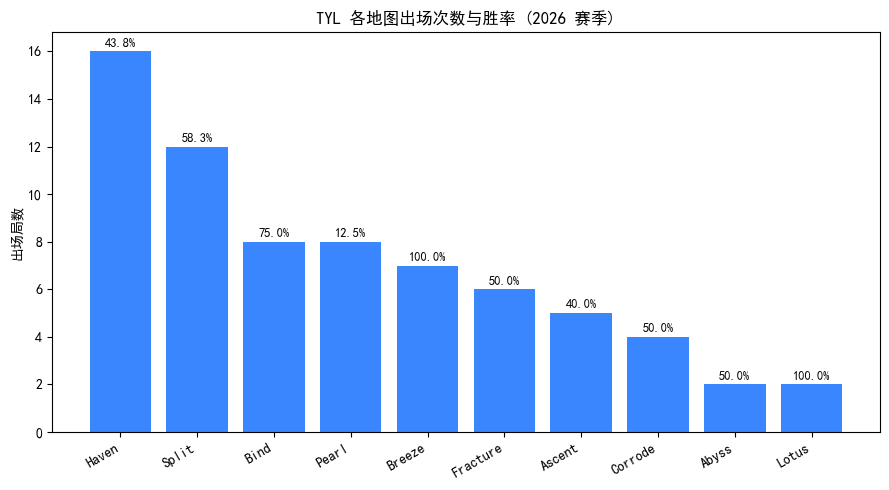

In [7]:
# 2.1 各地图出场次数与胜率
if not maps_df.empty:
    g = maps_df.groupby('map').agg(
        played   = ('map', 'size'),
        wins     = ('tyl_won', 'sum'),
    )
    g['win_rate'] = (g['wins'] / g['played'] * 100).round(1)
    g = g.sort_values('played', ascending=False)
    display(g)

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(g.index, g['played'], color='#3a86ff')
    # 在柱上标注胜率
    for bar, wr in zip(bars, g['win_rate']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{wr}%', ha='center', fontsize=9)
    ax.set_title(f'{TYL_SHORT} 各地图出场次数与胜率 (2026 赛季)')
    ax.set_ylabel('出场局数')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/01a_map_pool.png', dpi=150)
    plt.show()

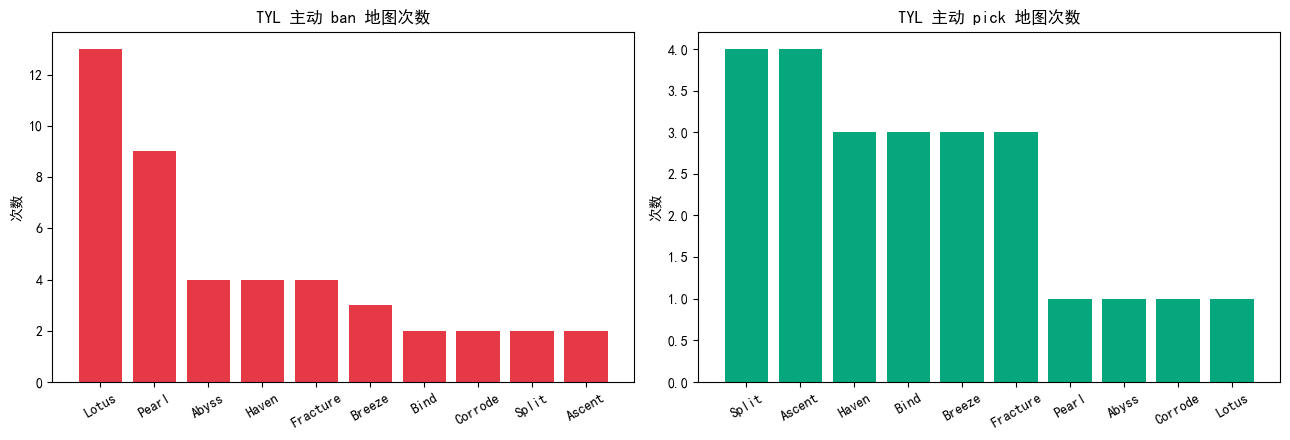

In [8]:
# 2.2 TYL 主动 ban / 主动 pick 偏好
if not picks_bans_df.empty:
    tyl_actions = picks_bans_df[picks_bans_df['is_tyl'] == True]
    tyl_bans  = tyl_actions[tyl_actions['action'] == 'ban']['map'].value_counts()
    tyl_picks = tyl_actions[tyl_actions['action'] == 'pick']['map'].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    if not tyl_bans.empty:
        axes[0].bar(tyl_bans.index, tyl_bans.values, color='#e63946')
        axes[0].set_title(f'{TYL_SHORT} 主动 ban 地图次数')
        axes[0].set_ylabel('次数')
        axes[0].tick_params(axis='x', rotation=30)
    if not tyl_picks.empty:
        axes[1].bar(tyl_picks.index, tyl_picks.values, color='#06a77d')
        axes[1].set_title(f'{TYL_SHORT} 主动 pick 地图次数')
        axes[1].set_ylabel('次数')
        axes[1].tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/01b_pickban.png', dpi=150)
    plt.show()

**解读**

TYL 的 BP 习惯很鲜明。Lotus 全赛季只打了 2 次,主动 ban 掉了 13 次,几乎是"打死也不打"的态度。Pearl 类似——主动 ban 9 次,但 BO3 只有四个 ban 的额度,挡不住对手反复送上来,出场了 8 次,胜率只有 12.5%。这两张图组合起来看,TYL 心里知道哪些是死穴,但 BP 资源不够用,Pearl 这个洞一直补不住。

主动 pick 数据里,Split 和 Ascent 各 4 次,是 TYL 自己挑选的主场。但真正有意思的是 Bind——主动 pick 只 3 次,出场却有 8 次,胜率 75%。要么是 TYL 自己低估了这张图,要么是对手把它当成"还能接受"的图反复送上门,结果反而成了 TYL 的隐藏强图。

另一个反差点是 Haven,出场最多(16 次),胜率却只有 43.8%,而主动 pick 只有 3 次。基本可以判断 Haven 不是 TYL 想打的图,而是决胜图剩下来、或者被对手 pick 上来的"被动接收"。出场多不等于擅长。

**对 FPX 的启示**

不要浪费 ban 位在 Lotus 和 Pearl 上,TYL 自己会处理掉。FPX 的 ban 应该花在 Bind 和 Breeze——这才是 TYL 真正想打、也真正能打的两张图。Pearl 和 Haven 是可以引导 TYL 去打的方向。

## 3. 维度二:特工与阵容选择

**看什么:** TYL 高频使用的特工、固定的阵容搭配;不同地图上的特工偏好。
**为什么:** 阵容反映战术体系 —— 偏控场、偏突破还是偏架枪,
也能看出 TYL 是否过度依赖某个特工。

TYL 使用过的特工: 21


Viper        36
Neon         34
Omen         32
Sova         26
Yoru         19
Cypher       19
Waylay       19
Fade         19
Astra        15
Brimstone    14
Jett         14
Skye         14
Killjoy      11
Raze          7
Kayo          7
dtype: int64

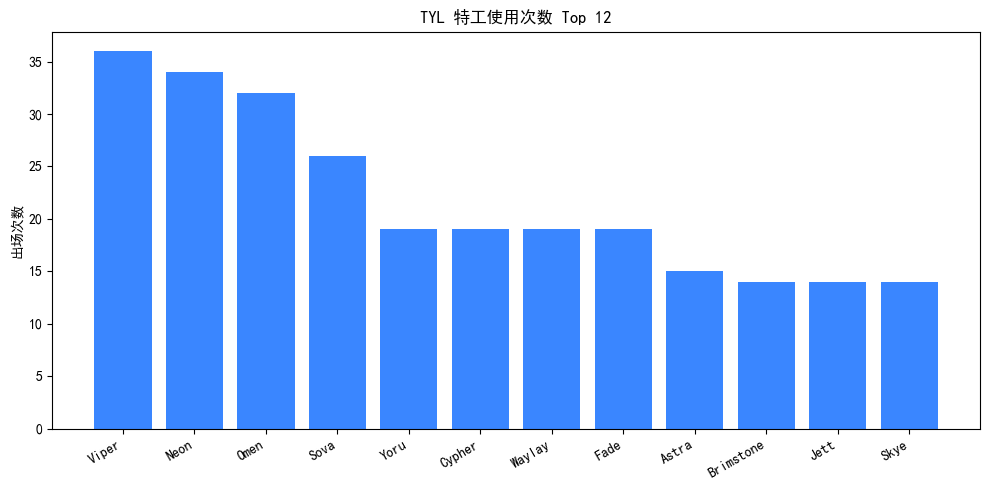

In [9]:
# 3.1 TYL 特工使用次数
tyl_comps = comps_df[comps_df['is_tyl']]
all_agents = [a for lst in tyl_comps['agents'] for a in lst]
agent_count = pd.Series(Counter(all_agents)).sort_values(ascending=False)
print('TYL 使用过的特工:', len(agent_count))
display(agent_count.head(15))

fig, ax = plt.subplots(figsize=(10, 5))
top = agent_count.head(12)
ax.bar(top.index, top.values, color='#3a86ff')
ax.set_title(f'{TYL_SHORT} 特工使用次数 Top 12')
ax.set_ylabel('出场次数')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02a_agent_pick.png', dpi=150)
plt.show()

In [10]:
# 3.2 不同地图上的 TYL 高频阵容
# 每张地图列出 TYL 出场 >= 2 次且最常用的阵容组合
tyl_comps_copy = tyl_comps.copy()
tyl_comps_copy['agents_str'] = tyl_comps_copy['agents'].apply(lambda x: ' / '.join(sorted(x)))

for m in maps_df['map'].value_counts().head(7).index:
    sub = tyl_comps_copy[tyl_comps_copy['map'] == m]
    if len(sub) < 2:
        continue
    print(f"\n=== {m} (共 {len(sub)} 局) ===")
    print(sub['agents_str'].value_counts().head(3).to_string())


=== Haven (共 16 局) ===
agents_str
Killjoy / Neon / Omen / Sova / Viper    7
                                        3
Cypher / Neon / Omen / Sova / Waylay    2

=== Split (共 12 局) ===
agents_str
Fade / Omen / Viper / Waylay / Yoru    5
Neon / Omen / Skye / Viper / Waylay    4
                                       2

=== Pearl (共 8 局) ===
agents_str
Astra / Killjoy / Neon / Sova / Yoru       3
Astra / Cypher / Fade / Neon / Phoenix     2
Astra / Chamber / Fade / Neon / Phoenix    1

=== Bind (共 8 局) ===
agents_str
Brimstone / Neon / Skye / Viper / Waylay    4
Brimstone / Fade / Raze / Viper / Yoru      3
Brimstone / Raze / Skye / Tejo / Viper      1

=== Breeze (共 7 局) ===
agents_str
Astra / Jett / Kayo / Sova / Viper    4
Astra / Jett / Sova / Viper / Yoru    2
                                      1

=== Fracture (共 6 局) ===
agents_str
Brimstone / Cypher / Neon / Skye / Tejo       3
Brimstone / Cypher / Neon / Phoenix / Tejo    1
Breach / Brimstone / Cypher / Jett / Tejo     1

=== 

**解读**

前四个特工出场次数(Viper 36、Neon 34、Omen 32、Sova 26)勾勒出来的体系非常清楚:双控场打底(Viper 配 Omen),Neon 拉进攻节奏,Sova 提供信息。整套阵容是进攻向的,围绕"控烟封图 + 快速突破"展开。

有两个细节值得多看一眼。

Yoru 19 次（只是分析，现在的环境夜路，霓虹的出场率会大幅降低，yoru已经进入下水道，霓虹的出场率在这次大师赛可能会从80%的选取率降低到50%以下）,在职业赛环境里这个使用率算偏高的——通常意味着队里有人主玩这个英雄。结合选手层面的特工数据,基本可以锁定是 splash(印尼籍,Jett/Waylay 双修的决斗位)。这种"体系吃核心 duelist 个人发挥"的结构,在打顺的时候是武器,打不开的时候是隐患——核心被压住，整队进攻容易卡壳。

另一个反常点是 Jett 只排到第 11(14 次)。传统职业赛 Jett 是 OP 位主力,使用率这么低,说明 TYL 把这块职责让给了 Neon 和 Yoru。攻击性更强,但代价是稳定性下降——Jett 那种"打不通就拉撤回防"的安全感,TYL 的体系里不太有。

**对 FPX 的启示**

针对 Viper 这种地图依赖型控场,直接绕开 TYL 的舒适区——前面看到的 Pearl、Abyss 这些 Viper 不强的图,正好对上。选手层面,赛前 video review 重点放在 splash 的决斗习惯上;比赛里关键回合优先 trade 掉这个人,TYL 的进攻很可能直接打不出来。

## 4. 维度三:攻防半场强弱

**看什么:** TYL 整体的进攻 / 防守半场回合胜率,以及在不同地图上的攻防差异。
**为什么:** 攻强守弱还是反之,直接影响对枪节奏与战术准备方向。

,rounds,wins,win_rate
tyl_side,,,
Attacker,647,357,55.2
Defender,623,299,48.0


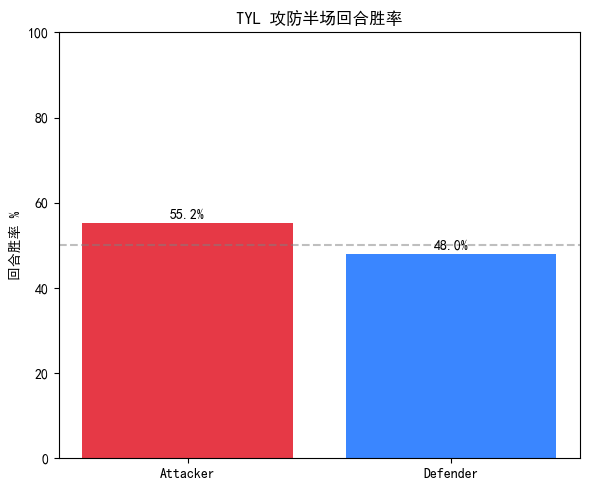

In [11]:
# 4.1 整体攻防半场胜率
side_stat = rounds_df.groupby('tyl_side').agg(
    rounds = ('tyl_side', 'size'),
    wins   = ('is_tyl_win', 'sum'),
)
side_stat['win_rate'] = (side_stat['wins'] / side_stat['rounds'] * 100).round(1)
display(side_stat)

fig, ax = plt.subplots(figsize=(6, 5))
colors = {'Attacker': '#e63946', 'Defender': '#3a86ff'}
ax.bar(side_stat.index, side_stat['win_rate'],
       color=[colors.get(x, 'gray') for x in side_stat.index])
for i, (idx, row) in enumerate(side_stat.iterrows()):
    ax.text(i, row['win_rate'] + 1, f"{row['win_rate']}%", ha='center')
ax.set_title(f'{TYL_SHORT} 攻防半场回合胜率')
ax.set_ylabel('回合胜率 %')
ax.set_ylim(0, 100)
ax.axhline(50, ls='--', color='gray', alpha=0.5)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/03a_atk_def.png', dpi=150)
plt.show()

,atk_wr,def_wr
map,,
Lotus,78.3,36.4
Breeze,64.1,56.2
Bind,58.3,68.2
Haven,56.9,39.1
Split,54.5,47.8
Corrode,53.5,50.0
Ascent,52.8,42.1
Fracture,50.8,45.8
Abyss,44.4,37.5


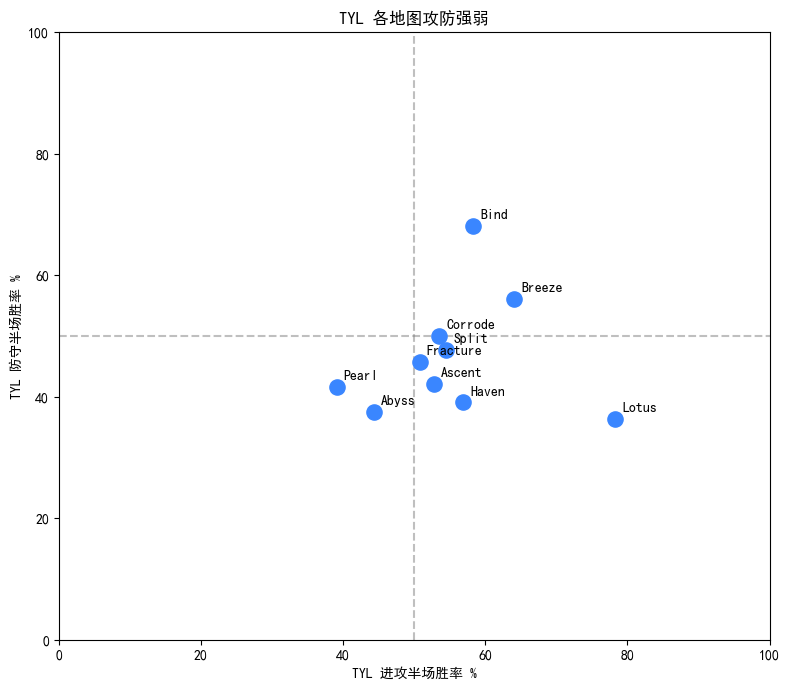

In [12]:
# 4.2 分地图的攻防胜率
g = maps_df.groupby('map').agg(
    atk_won = ('tyl_atk_rounds', 'sum'),
    def_won = ('tyl_def_rounds', 'sum'),
    opp_atk = ('opp_atk_rounds', 'sum'),   # 当 TYL 防守时,对手在进攻
    opp_def = ('opp_def_rounds', 'sum'),   # 当 TYL 进攻时,对手在防守
)
# TYL 当攻方的回合 = TYL 进攻得分 + 对手防守得分
g['tyl_atk_rounds_total'] = g['atk_won'] + g['opp_def']
g['tyl_def_rounds_total'] = g['def_won'] + g['opp_atk']
g['atk_wr'] = (g['atk_won'] / g['tyl_atk_rounds_total'] * 100).round(1)
g['def_wr'] = (g['def_won'] / g['tyl_def_rounds_total'] * 100).round(1)
g = g[['atk_wr', 'def_wr']].sort_values('atk_wr', ascending=False)
display(g)

# 散点图:每张地图一个点,横轴攻击胜率、纵轴防守胜率
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(g['atk_wr'], g['def_wr'], s=120, color='#3a86ff', zorder=3)
for name, row in g.iterrows():
    ax.annotate(name, (row['atk_wr'], row['def_wr']),
                xytext=(5, 5), textcoords='offset points', fontsize=10)
ax.axhline(50, ls='--', color='gray', alpha=0.5)
ax.axvline(50, ls='--', color='gray', alpha=0.5)
ax.set_xlabel('TYL 进攻半场胜率 %')
ax.set_ylabel('TYL 防守半场胜率 %')
ax.set_title(f'{TYL_SHORT} 各地图攻防强弱')
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/03b_atk_def_by_map.png', dpi=150)
plt.show()

**解读**

整体数字:进攻 55.2%,防守 48.0%。TYL 是一支偏进攻型的队伍。这一点和"CN 赛区偏架枪、偏防守"的传统印象是反着的,值得留意——FPX 不能套用对 CN 队伍的常规预期。

分图散点图把这件事讲得更细。

Bind 在右上角,攻 58 / 防 68,68% 的防守胜率是全部地图里最高的——这才是 TYL 真正的本命。Breeze 攻 65 / 防 56,也是舒服区。Lotus 攻 78 / 防 36 看着夸张,但样本只有 2 局,**先不下结论**。

左下方一排是 TYL 的麻烦图。Pearl 攻 39 / 防 42,前面 12.5% 的胜率在这里有了解释——攻防两端都打不出来。Abyss 攻 44 / 防 37 同类情况。

最值得说的是 Haven。出场 16 次最多,但攻 57 / 防 39,防守端漏水严重。这就是为什么"出场最多、胜率最低"——TYL 在 Haven 攻击端还行,但守不住,被打到崩。

**对 FPX 的启示**

这一节的结论非常具体、非常可执行:Haven 上如果拿到选边权,**坚决选进攻**——TYL 防守 39%,这是直接吃下的便宜。Pearl 同理,选进攻,TYL 防守 42%。Bind 上避免和 TYL 打防守对枪,这是它的最强半场。

## 5. 维度四:对局节奏

**看什么:** TYL 对局的平均总回合数、加时局占比、滚雪球倾向。
**为什么:** 平均回合数高说明对局胶着;低则常打出滚雪球。

平均总回合数: 20.8
加时局(>24 回合)占比: 10.0%
碾压局(分差>=10)占比: 11.4%


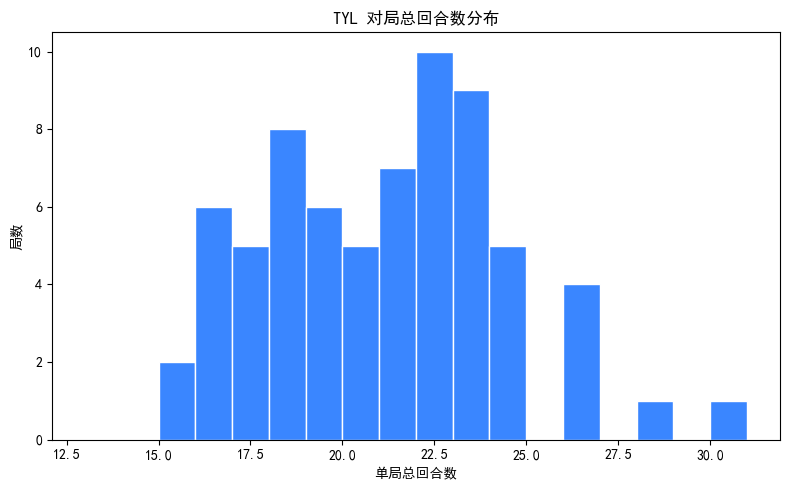

In [13]:
if not maps_df.empty:
    print(f"平均总回合数: {maps_df['total_rounds'].mean():.1f}")
    print(f"加时局(>24 回合)占比: {(maps_df['total_rounds']>24).mean()*100:.1f}%")
    print(f"碾压局(分差>=10)占比: {((maps_df['tyl_score']-maps_df['opp_score']).abs()>=10).mean()*100:.1f}%")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(maps_df['total_rounds'], bins=range(13, 32), color='#3a86ff', edgecolor='white')
    ax.set_title(f'{TYL_SHORT} 对局总回合数分布')
    ax.set_xlabel('单局总回合数')
    ax.set_ylabel('局数')
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/04_pace.png', dpi=150)
    plt.show()

**解读**

回合数主要集中在 22-24 区间,典型的胶着对局。但左尾(15-18 回合)也聚集了不少样本,说明 TYL 既打过把对手摁住的滚雪球局,也被对手滚雪球过——两边都有戏。

这种分布意味着两件事。一是 FPX 准备打 TYL 的时候,要按"打满、可能拖加时"的预期来准备,体能和心态都得跟得上。二是开局回合极其关键——TYL 进攻强,一旦让他们前段上手,雪球往往收不住;反过来,如果 FPX 能在前几个回合把节奏抢下来,TYL 这种"吃核心 duelist 发挥"的体系一旦没打开,后面容易越打越拘谨。

## 6. 维度五:手枪局表现

**看什么:** TYL 在手枪局(第 1、13 回合)的胜率,以及手枪局赢下后能否扩大优势。
**为什么:** 手枪局牵动后续 4-5 个回合的经济,是高价值环节。

> 注:vlrdevapi 返回的字段里 fk/fd(首杀/首死)为 null,所以本项目用手枪局胜率代替"首杀转化率"维度。

In [14]:
pistol = rounds_df[rounds_df['is_pistol']]
if not pistol.empty:
    overall_wr = pistol['is_tyl_win'].mean() * 100
    print(f'TYL 手枪局胜率: {overall_wr:.1f}%  (样本 {len(pistol)} 个手枪局)')

    # 按攻防分:第 1 回合 TYL 哪一边
    by_side = pistol.groupby('tyl_side').agg(
        rounds=('tyl_side', 'size'),
        wins  =('is_tyl_win', 'sum'),
    )
    by_side['win_rate'] = (by_side['wins'] / by_side['rounds'] * 100).round(1)
    print('\n按攻防分手枪局胜率:')
    display(by_side)

TYL 手枪局胜率: 49.2%  (样本 122 个手枪局)

按攻防分手枪局胜率:


,rounds,wins,win_rate
tyl_side,,,
Attacker,61,32,52.5
Defender,61,28,45.9


**解读**

手枪局是经济的源头——赢一手通常能带 2-3 个 bonus,直接影响整个半场的节奏。这个胜率数字(见上方打印)是 FPX 备战的直接锚点:

- 如果 TYL 手枪局胜率明显过半,意味着对 TYL 的比赛"赢手枪"几乎是 FPX 必须的目标,赛前需要重点过手枪局的执行细节(起手点位、第一波信息),不然容易在前段被经济差拉开。
- 如果接近五五或者偏低,FPX 的目标可以放宽到"输手枪也能 force 一波回来",压力分散一些。

具体哪种情况,看上面跑出来的数字决定。

**对 FPX 的启示**

无论数字落到哪边,结合维度四"开局重要"的结论,第一回合和第十三回合的执行准备都应该是 FPX 训练里的重点之一。

## 7. 战术启示 —— 给 FPX 的 BP 建议与反制策略

下面是把前面六节的数据收拢成可执行建议。所有判断对应上方图表的具体数字,以教练组能直接拿去用的语言写。

### BP 阶段:别白白送 ban,把火力放在 Bind 和 Breeze

TYL 自己会主动 ban 掉 Lotus(全赛季 13 次)和 Pearl(9 次),所以 FPX 完全没必要在这两张图上浪费 ban 位。把 ban 留给 TYL 真正打得舒服、也真正会主动 pick 的图——Bind 和 Breeze。Bind 攻 58 / 防 68,是 TYL 的本命中的本命;Breeze 在 Viper 体系下攻防双强,出场胜率也接近顶。这两张图能 ban 掉一张,TYL 的舒适区就缺一角。

如果有选图权,优先把对局往 Pearl(TYL 胜率 12.5%)和 Haven(43.8%)上引。这两张图 TYL 都打过不少,数据样本足,结论可靠。

### 选边:三张图三条具体建议

Haven 上选**进攻**——TYL 防守只有 39%,这是数据直接给出的最大便宜。出场 16 次的样本量足够支撑这个结论。

Pearl 上同样选**进攻**——TYL 防守 42%。

Bind 上,如果不得不打,**避免和 TYL 打防守对枪**。TYL 在 Bind 的防守半场 68% 是它的最强战线,FPX 拉到这里硬碰大概率吃亏。

### 阵容针对:绕开 Viper,trade 掉 splash

TYL 的体系核心是 Viper,所以选 Viper 不强的图(Pearl 本身就是)能直接绕开。这也是为什么前面"Pearl 引导"的建议在 BP 和阵容两层逻辑上都成立。

选手层面,splash 是 TYL 的个人能力支点(Jett/Waylay/Yoru 主玩,决斗位)。Yoru 出场 19 次的反常使用率几乎可以确认这个人是 one-trick 风格的核心。赛前 review 重点放在他的决斗习惯上;比赛里关键回合(尤其是手枪局和 anti-eco)优先 trade 掉这个人。TYL 的进攻体系吃他发挥,一旦他被压住,整个进攻容易卡壳。

### 节奏:做好打满准备,但开局必须强

回合数分布显示 TYL 的对局以胶着居多,FPX 要按"打满、可能拖加时"的预期备战,体能、心态、轮转执行都要跟得上。

但开局不能松。TYL 进攻强,前段一旦被他们抢到节奏,容易被一波带走;反过来,如果 FPX 能把头几个回合的执行强度顶起来,TYL 这种依赖核心 duelist 发挥的体系打不顺时,往往会越打越拘谨。手枪局和 anti-eco 是这个"开局压制"的核心抓手。

### 一句话总结

> **TYL 是一支 BP 鲜明、靠 Viper 体系和 splash 个人发挥推动进攻的偏攻型队伍,Bind 和 Breeze 是真正的本命,Pearl 是怎么挡都挡不住的死穴,Haven 是出场最多但守不住的"决胜图陷阱"。FPX 的针对策略集中在三点:BP 上 ban 死 Bind 和 Breeze,选边时凡是能选进攻就选进攻(Haven、Pearl 尤其如此),比赛中重点 trade 掉 splash。**

---

### 数据与方法说明

- **数据范围:** TYL 2026 赛季全部已抓取到的职业对局,共 26 个 BO,涵盖 启点赛、第一赛段、China Evolution Series、EWC China Qualifier 等阶段。
- **数据来源:** VLR.gg,经 vlrdevapi 抓取于 2026-06-06。
- **局限:**
  - 样本限于 26 个 BO,部分地图(Lotus、Abyss)地图层样本仅 2 局,结论保守。
  - 阵容/选手在赛季中可能调整,以最新阵容信息为准。
  - 首杀(first kill)、ADR、KAST 等细颗粒度数据 vlrdevapi 不返回,因此首杀转化率维度未做。
- **代码与数据:** 见本项目 GitHub 仓库(待补)。